# Environment Setup

In [1]:
import sys
import os

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

# Imports

In [2]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import model.assumptions as assumptions_module
import model.policy as policy_module
import model.projection as projection_module
import model.valuation as valuation_module
import model.results as results_module
import model.analysis.profit as profit_analysis

plt.style.use("seaborn-v0_8")

# Reload Modules

In [3]:
def reload_all():

    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(projection_module)
    importlib.reload(results_module)
    importlib.reload(valuation_module)
    importlib.reload(profit_analysis)

reload_all()

# Notebook Entry Points 
import model.valuation as valuation 
import model.analysis.profit as profit_analysis 
import model.assumptions as assumptions_module 
import model.policy as policy_module

# Assumptions Setup

In [4]:
mortality = assumptions_module.MortalityTable()

interest = assumptions_module.FlatYieldCurve(
    interest_rate=0.03
)

assumptions = assumptions_module.AssumptionSet(
    mortality=mortality,
    interest=interest
)

# Single Policy Setup

In [5]:
policy = policy_module.Policy(
    age=40,
    term=20,
    sum_assured=100000,
    premium=1200
)

# Projection Analysis

In [6]:
projection = projection_module.project_cashflows(
    policy,
    assumptions
)

projection

projection.rows[0]

ProjectionRow(t=0, age=40, prob_alive=1.000000, qx=0.001113)

# Run valuation

In [7]:
valuation_result = valuation_module.value_policy(
    policy,
    assumptions,
    return_breakdown=True
)

# Core results

In [8]:
summary = {
    "PV Premiums": valuation_result.pv_premiums,
    "PV Claims": valuation_result.pv_claims,
    "Net Value": valuation_result.net_value
}

pd.Series(summary)

PV Premiums    18098.018352
PV Claims       3664.721100
Net Value      14433.297252
dtype: float64

# Build Analysis Dataset

In [9]:
df = profit_analysis.build_profit_dataframe(valuation_result)
df = profit_analysis.add_profit_signature(df)

# Profit Emergence Table

In [10]:
df[["t",
    "net_cashflow",
    "cum_cashflow",
    "pv_net",
    "cum_profit"
]].round(2)

,t,net_cashflow,cum_cashflow,pv_net,cum_profit
0,0,1088.72,1088.72,1088.72,1088.72
1,1,1078.25,2166.98,1046.85,2135.57
2,2,1066.94,3233.91,1005.69,3141.26
3,3,1054.71,4288.62,965.21,4106.47
4,4,1041.49,5330.11,925.35,5031.82
5,5,1027.22,6357.33,886.09,5917.91
6,6,1011.80,7369.13,847.37,6765.27
7,7,995.15,8364.28,809.15,7574.42
8,8,977.18,9341.46,771.40,8345.82
9,9,957.79,10299.25,734.07,9079.89


# Profit Signature

In [11]:
df[["t", "pv_net", "profit_pct"]].round(4)

,t,pv_net,profit_pct
0,0,1088.7230,0.0754
1,1,1046.8484,0.0725
2,2,1005.6909,0.0697
3,3,965.2068,0.0669
4,4,925.3530,0.0641
5,5,886.0868,0.0614
6,6,847.3661,0.0587
7,7,809.1495,0.0561
8,8,771.3960,0.0534
9,9,734.0654,0.0509


# Summary Metrics

In [12]:
pd.Series(profit_analysis.summary_metrics(df))

total_pv_profit      14433.297252
total_cash_profit    18413.192149
peak_profit_year         0.000000
dtype: float64

# Visualisations

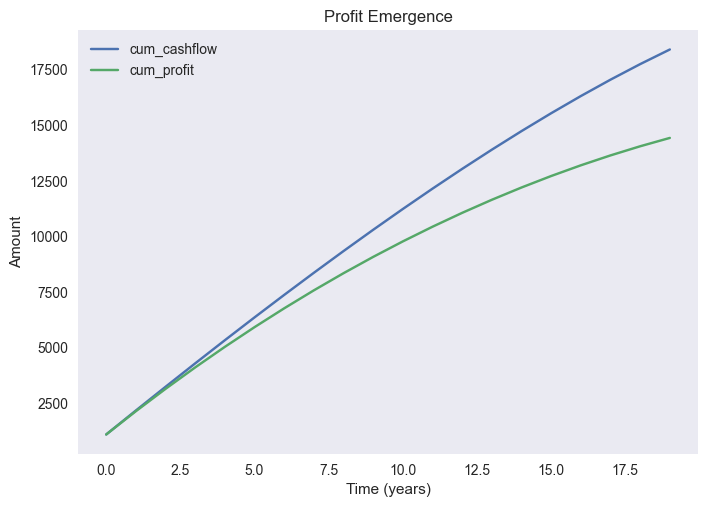

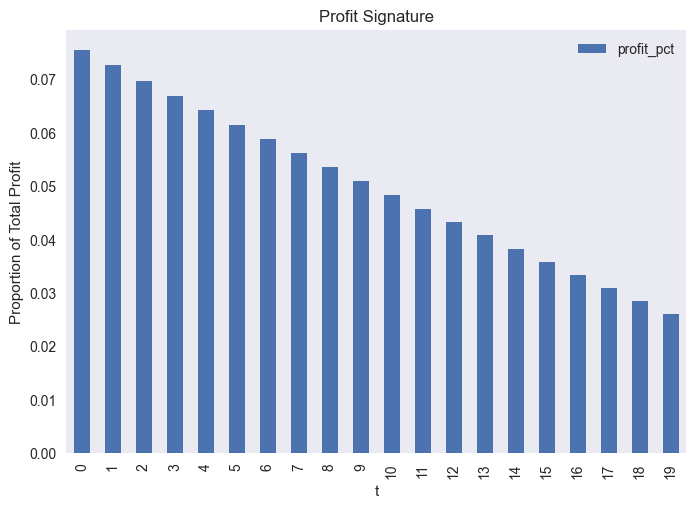

In [13]:
# Profit Emergence

df.plot(x="t", y=["cum_cashflow", "cum_profit"])
plt.title("Profit Emergence")
plt.ylabel("Amount")
plt.xlabel("Time (years)")
plt.grid()
plt.show()


# Profit Signature

df.plot(x="t", y="profit_pct", kind="bar")
plt.title("Profit Signature")
plt.ylabel("Proportion of Total Profit")
plt.grid()
plt.show()